[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

<class 'pandas.core.frame.DataFrame'>


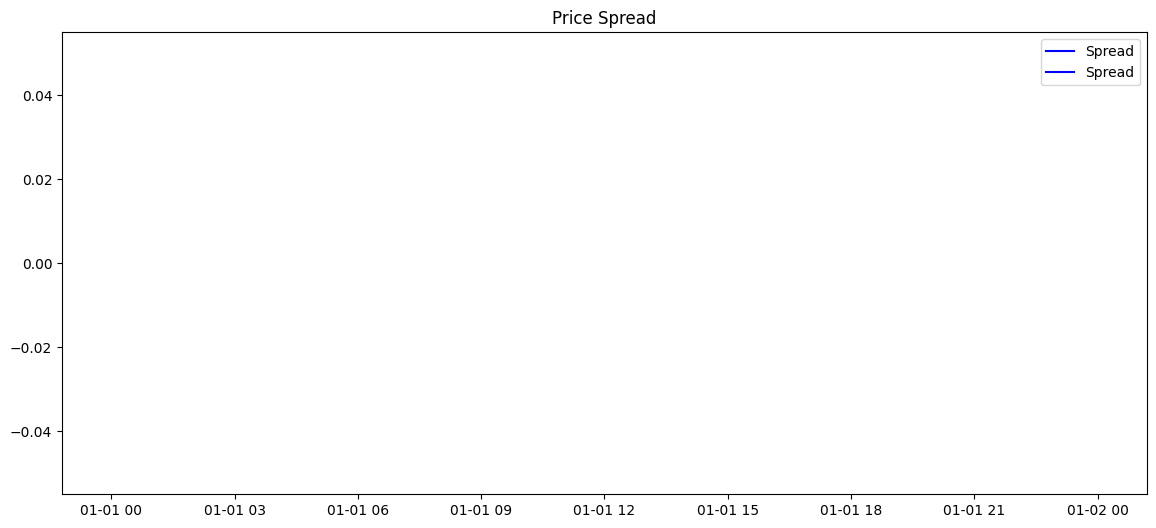

In [51]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt


# Example pair: Coca-Cola and Pepsi

ticker_A = "MT"
ticker_B = "VALE"
price_A = yf.download(ticker_A, period="5y")["Close"].dropna()
price_B = yf.download(ticker_B, period="5y")["Close"].dropna()

spread = price_A - price_B
print(type(price_A))
plt.figure(figsize=(14, 6))
plt.plot(spread, label="Spread", color='blue')

plt.title("Price Spread")
plt.legend()
plt.show()


In [52]:
from pykalman import KalmanFilter

# Prepare data
y = price_A.values.flatten()  # dependent variable (stock A)
x = price_B.values.flatten()  # independent variable (stock B)
print(f"Data shapes - x: {x.shape}, y: {y.shape}")

n_timesteps = len(y)
n_dim_state = 2  # [beta, alpha]
n_dim_obs = 1    # univariate observation (y)

# State transition matrix (2x2) - random walk for beta and alpha
transition_matrices = np.eye(n_dim_state)

# Observation matrix (time-varying) - shape should be (n_timesteps, n_dim_obs, n_dim_state)
observation_matrices = np.zeros((n_timesteps, n_dim_obs, n_dim_state))
for t in range(n_timesteps):
    observation_matrices[t, 0, 0] = float(x[t])  # coefficient for beta
    observation_matrices[t, 0, 1] = 1.0   # coefficient for alpha

# Initial state
initial_state_mean = np.zeros(n_dim_state)
initial_state_covariance = np.eye(n_dim_state)

# Observation covariance (1x1 matrix for univariate observation)
observation_covariance = 1.0

# Transition covariance (2x2)
delta = 1e-5
transition_covariance = delta / (1 - delta) * np.eye(n_dim_state)

# Print all shapes for verification
print(f"transition_matrices shape: {transition_matrices.shape}")
print(f"observation_matrices shape: {observation_matrices.shape}")
print(f"initial_state_mean shape: {initial_state_mean.shape}")
print(f"initial_state_covariance shape: {initial_state_covariance.shape}")
# print(f"observation_covariance shape: {observation_covariance.shape}")
print(f"transition_covariance shape: {transition_covariance.shape}")
print(f"y shape: {y.shape}")

# Expected shapes for PyKalman:
# - transition_matrices: (n_dim_state, n_dim_state) = (2, 2)
# - observation_matrices: (n_timesteps, n_dim_obs, n_dim_state) = (n, 1, 2)
# - initial_state_mean: (n_dim_state,) = (2,)
# - initial_state_covariance: (n_dim_state, n_dim_state) = (2, 2)
# - observation_covariance: (n_dim_obs, n_dim_obs) = (1, 1)
# - transition_covariance: (n_dim_state, n_dim_state) = (2, 2)

# Initialize Kalman Filter
kf = KalmanFilter(
    transition_matrices=transition_matrices,
    observation_matrices=observation_matrices,
    initial_state_mean=initial_state_mean,
    initial_state_covariance=initial_state_covariance,
    observation_covariance=observation_covariance,
    transition_covariance=transition_covariance
)

# Run Kalman Filter
print(y.shape)
state_means, _ = kf.filter(y)
hedge_ratios = state_means[:, 0]  # β_t
intercepts = state_means[:, 1]


Data shapes - x: (1257,), y: (1257,)
transition_matrices shape: (2, 2)
observation_matrices shape: (1257, 1, 2)
initial_state_mean shape: (2,)
initial_state_covariance shape: (2, 2)
transition_covariance shape: (2, 2)
y shape: (1257,)
(1257,)


In [53]:
# spread = y - hedge_ratios * x - intercepts

# plt.figure(figsize=(14, 6))
# plt.plot(spread, label='Kalman Filter Spread')
# plt.axhline(spread.mean(), color='r', linestyle='--', label='Mean')
# plt.legend()
# plt.title("Mean-Reverting Spread from Kalman Filter")
# plt.show()


(1257,)
Kalman Filter executed successfully!
Final hedge ratio: 2.3336
Final intercept: 7.3585
Spread mean: 0.3372
Spread std: 1.7330


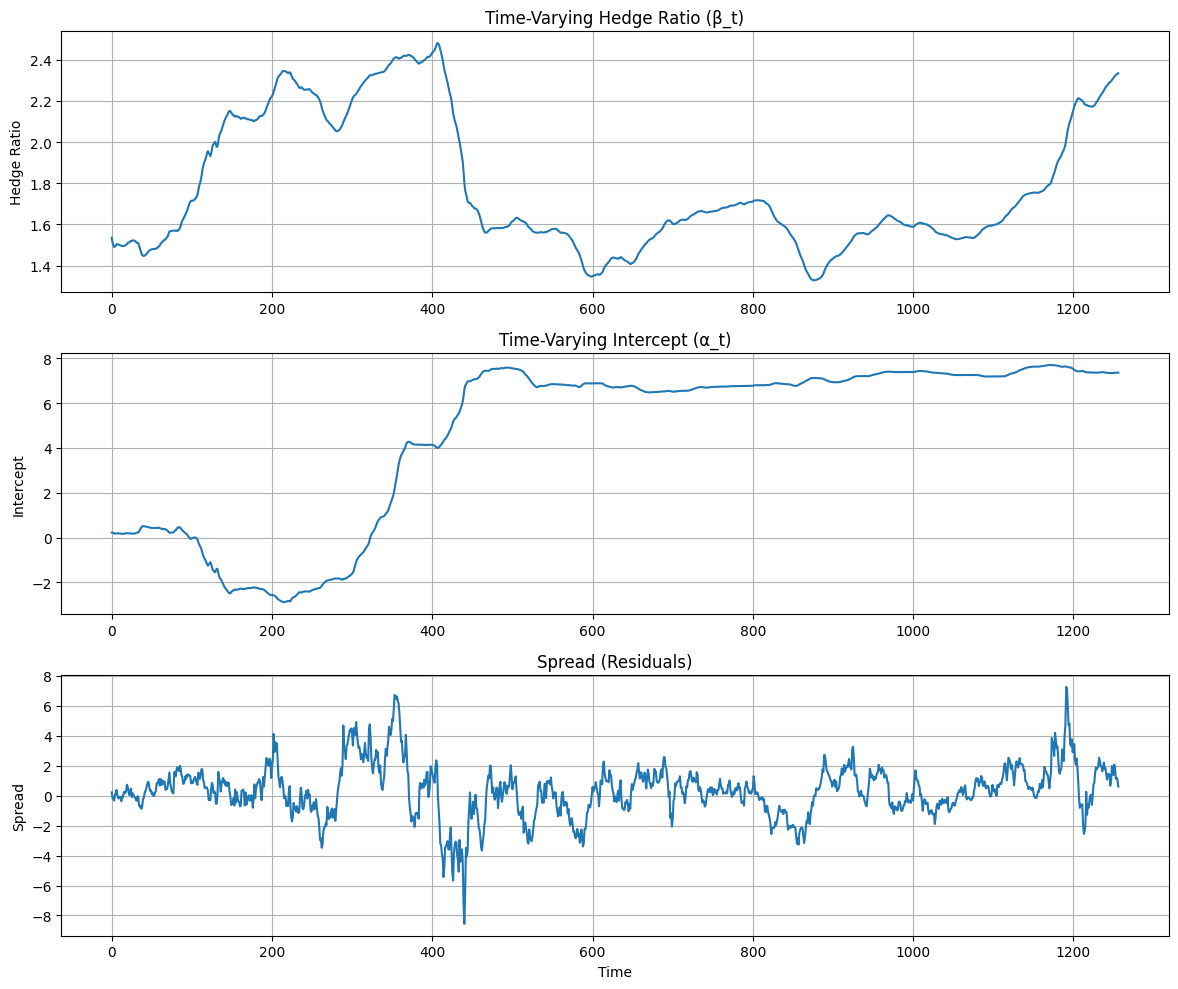

In [54]:
spread = y - (hedge_ratios * x + intercepts)
print(spread.shape)

print("Kalman Filter executed successfully!")
print(f"Final hedge ratio: {hedge_ratios[-1]:.4f}")
print(f"Final intercept: {intercepts[-1]:.4f}")
print(f"Spread mean: {np.mean(spread):.4f}")
print(f"Spread std: {np.std(spread):.4f}")

# Plot results
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# Plot hedge ratio over time
axes[0].plot(hedge_ratios)
axes[0].set_title('Time-Varying Hedge Ratio (β_t)')
axes[0].set_ylabel('Hedge Ratio')
axes[0].grid(True)

# Plot intercept over time
axes[1].plot(intercepts)
axes[1].set_title('Time-Varying Intercept (α_t)')
axes[1].set_ylabel('Intercept')
axes[1].grid(True)

# Plot spread
axes[2].plot(spread)
axes[2].set_title('Spread (Residuals)')
axes[2].set_ylabel('Spread')
axes[2].set_xlabel('Time')
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [55]:
def zscore(series):
    return (series - series.mean()) / series.std()

z = zscore(pd.Series(spread))

# Signal logic
positions_A = np.where(z < -1.5, 1.5, np.where(z > 1.5, -1.5, 0))
positions_B = -hedge_ratios * positions_A

longs = z < -2
shorts = z > 2
exits = np.abs(z) < 0.1  # small band for exit


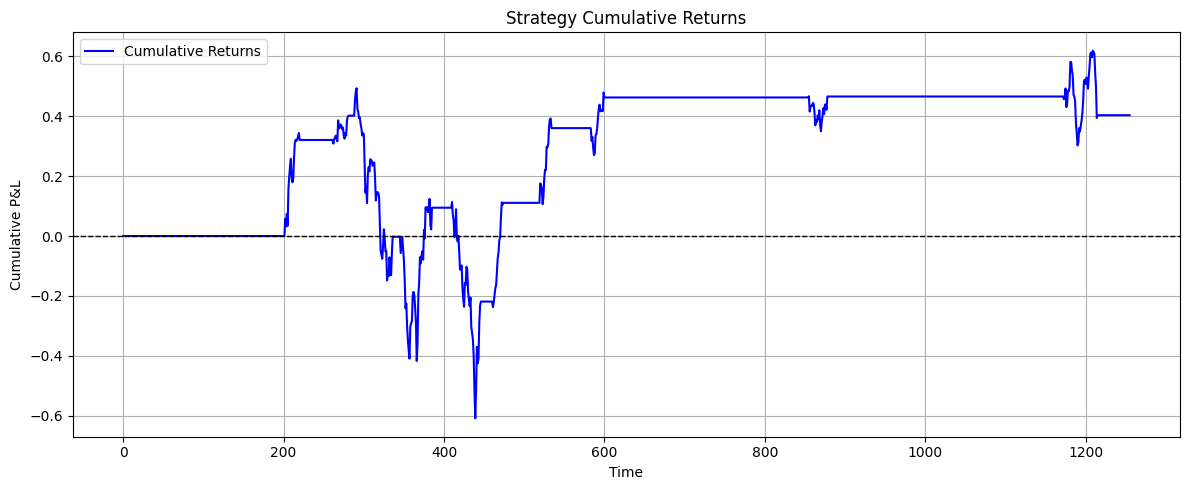

Sharpe Ratio: 0.24


In [56]:
position = np.zeros_like(z)
for t in range(1, len(z)):
    if longs[t]:
        position[t] = 1
    elif shorts[t]:
        position[t] = -1
    elif exits[t]:
        position[t] = 0
    else:
        position[t] = position[t-1]

# returns
ret_A = np.diff(y) / y[:-1]
ret_B = np.diff(x) / x[:-1]

# align positions
position = position[:-1]
hedge = hedge_ratios[:-1]

# position in A is +1/-1, B is -hedge*A
ret = position * ret_A + (-position * hedge) * ret_B
cumulative_returns = np.cumsum(ret)
plt.figure(figsize=(12, 5))
plt.plot(cumulative_returns, label='Cumulative Returns', color='blue')
plt.axhline(0, linestyle='--', color='black', linewidth=1)
plt.title("Strategy Cumulative Returns")
plt.xlabel("Time")
plt.ylabel("Cumulative P&L")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

sharpe_ratio = np.mean(ret) / np.std(ret) * np.sqrt(252)  # assuming daily data
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")


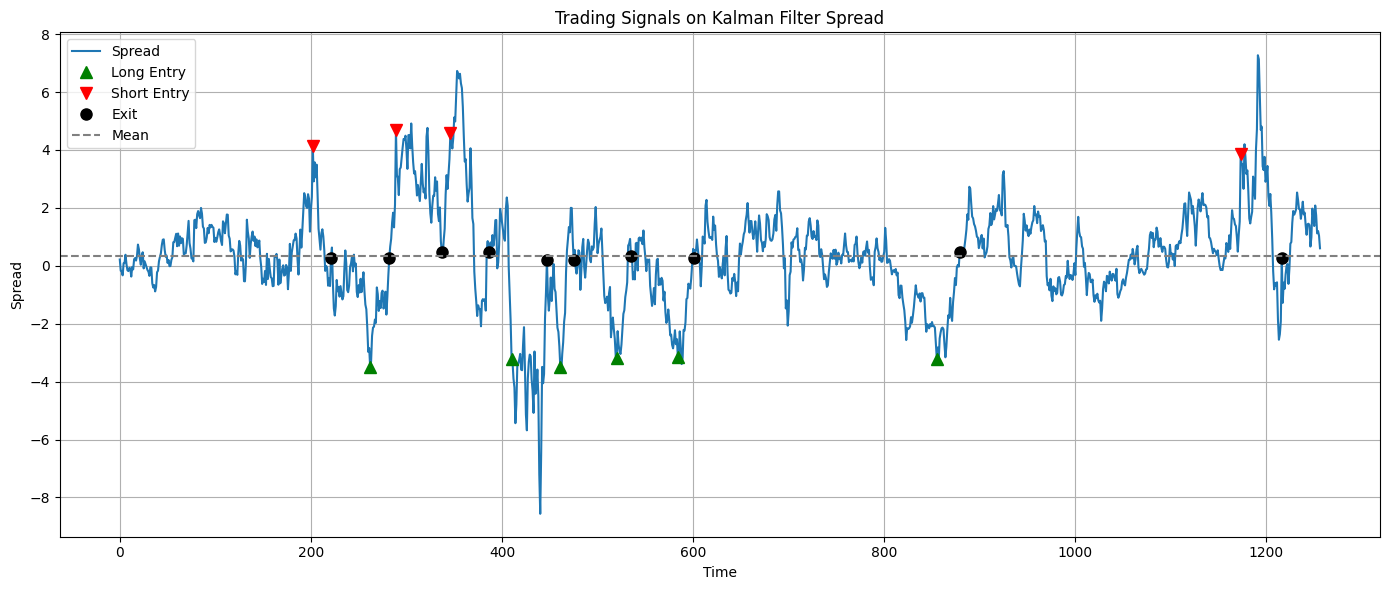

In [57]:
plt.figure(figsize=(14,6))
plt.plot(spread, label='Spread')

# Find actual times (indices) for entries and exits
entry_long_idx = np.where((position[1:] == 1) & (position[:-1] == 0))[0] + 1
entry_short_idx = np.where((position[1:] == -1) & (position[:-1] == 0))[0] + 1
exit_idx = np.where((position[1:] == 0) & (position[:-1] != 0))[0] + 1

plt.plot(entry_long_idx, spread[entry_long_idx], '^', markersize=8, color='g', label='Long Entry')
plt.plot(entry_short_idx, spread[entry_short_idx], 'v', markersize=8, color='r', label='Short Entry')
plt.plot(exit_idx, spread[exit_idx], 'o', markersize=8, color='black', label='Exit')

plt.axhline(np.mean(spread), color='grey', linestyle='--', label='Mean')
plt.title('Trading Signals on Kalman Filter Spread')
plt.xlabel('Time')
plt.ylabel('Spread')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
